In [2]:
import pandas as pd

In [3]:
df = pd.read_csv(r"C:\Users\User\Downloads\archive\synthetic_it_support_tickets.csv")

In [4]:
df.head()

,ticket_id,created_at,customer_id,customer_segment,channel,product_area,issue_type,priority,status,sla_plan,initial_message,agent_first_reply,resolution_summary,resolution_time_hours,reopened,customer_sentiment,csat_score,has_attachment,platform,region
0,TCKT_000001,2024-01-31T05:14:27,CUST_00861,individual,email,data_export,account_access,low,resolved,standard,I cannot log in; the system says my password i...,Sorry to hear you're having trouble accessing ...,Reset account credentials and confirmed succes...,36.53,0,very_negative,1,0,android,EU
1,TCKT_000002,2024-10-20T06:15:49,CUST_00770,individual,in_app,billing,security_concern,medium,closed_no_action,standard,I noticed a suspicious login on my account.,We take security very seriously. Our team is r...,Ticket closed without further action after no ...,238.32,0,neutral,3,0,web,NaN
2,TCKT_000003,2024-06-18T21:35:54,CUST_02559,small_business,chat,api_integration,bug,low,in_progress,standard,The api integration feature is not saving my c...,Thanks for reporting this bug. We will look in...,NaN,NaN,0,neutral,3,0,android,MEA
3,TCKT_000004,2025-12-25T15:59:52,CUST_03557,education,chat,analytics_dashboard,account_access,medium,in_progress,standard,I cannot log in; the system says my password i...,Sorry to hear you're having trouble accessing ...,NaN,NaN,0,positive,5,1,android,LATAM
4,TCKT_000005,2023-08-27T16:08:33,CUST_09556,enterprise,phone_transcript,login_auth,billing_problem,low,resolved,gold,My invoice amount is incorrect compared to the...,Thanks for reaching out about the billing issu...,Adjusted the invoice and issued a refund where...,61.32,0,very_negative,2,0,web,NaN


In [5]:
df.shape

(100000, 20)

In [6]:
df.columns

Index(['ticket_id', 'created_at', 'customer_id', 'customer_segment', 'channel',
       'product_area', 'issue_type', 'priority', 'status', 'sla_plan',
       'initial_message', 'agent_first_reply', 'resolution_summary',
       'resolution_time_hours', 'reopened', 'customer_sentiment', 'csat_score',
       'has_attachment', 'platform', 'region'],
      dtype='object')

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.describe()

,resolution_time_hours,reopened,csat_score,has_attachment
count,60113.000000,100000.000000,100000.000000,100000.000000
mean,45.013123,0.050450,2.241950,0.249520
std,49.202797,0.218873,1.771599,0.432737
min,0.110000,0.000000,0.000000,0.000000
25%,14.880000,0.000000,0.000000,0.000000
50%,29.910000,0.000000,2.000000,0.000000
75%,51.660000,0.000000,4.000000,0.000000
max,239.960000,1.000000,5.000000,1.000000


In [9]:
df.describe(include='object')

,ticket_id,created_at,customer_id,customer_segment,channel,product_area,issue_type,priority,status,sla_plan,initial_message,agent_first_reply,resolution_summary,customer_sentiment,platform,region
count,100000,100000,100000,100000,100000,100000,100000,100000,100000,100000,100000,100000,60113,100000,100000,80003
unique,100000,99959,9999,5,5,7,8,4,5,3,96,32,9,5,5,4
top,TCKT_099961,2023-12-28T02:25:35,CUST_07153,small_business,phone_transcript,mobile_app,how_to,low,resolved,standard,"Something seems off, can you please check my w...",Happy to help with your question. We will look...,Ticket closed without further action after no ...,neutral,api_client,MEA
freq,1,2,26,20203,20133,14432,12739,39735,50131,60066,4279,5055,9982,32634,20095,20151


In [10]:
df.isnull().sum()

ticket_id                    0
created_at                   0
customer_id                  0
customer_segment             0
channel                      0
product_area                 0
issue_type                   0
priority                     0
status                       0
sla_plan                     0
initial_message              0
agent_first_reply            0
resolution_summary       39887
resolution_time_hours    39887
reopened                     0
customer_sentiment           0
csat_score                   0
has_attachment               0
platform                     0
region                   19997
dtype: int64

In [11]:
df.dtypes

ticket_id                 object
created_at                object
customer_id               object
customer_segment          object
channel                   object
product_area              object
issue_type                object
priority                  object
status                    object
sla_plan                  object
initial_message           object
agent_first_reply         object
resolution_summary        object
resolution_time_hours    float64
reopened                   int64
customer_sentiment        object
csat_score                 int64
has_attachment             int64
platform                  object
region                    object
dtype: object

In [12]:
missing = df.isnull().sum()
missing[missing > 0]

resolution_summary       39887
resolution_time_hours    39887
region                   19997
dtype: int64

issue_type
how_to              12739
account_access      12609
performance         12513
feature_request     12487
other               12463
security_concern    12458
billing_problem     12382
bug                 12349
Name: count, dtype: int64


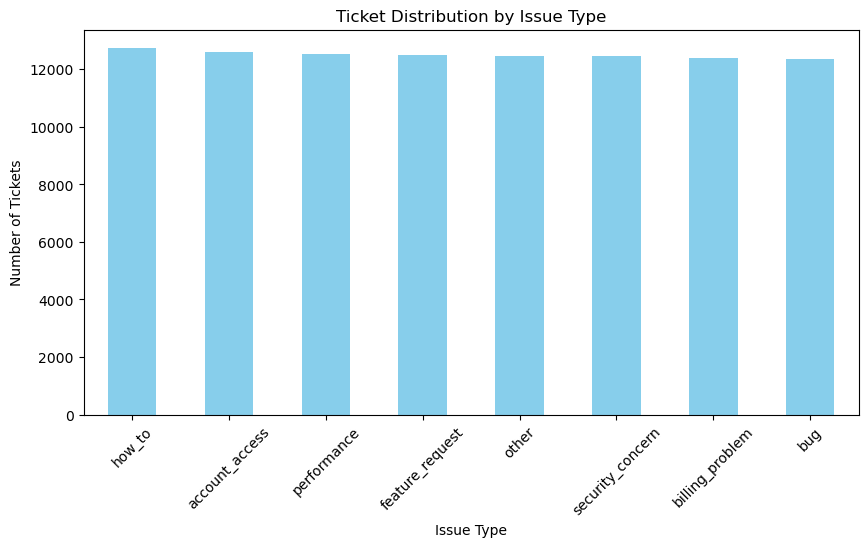

In [13]:
import matplotlib.pyplot as plt

# Count tickets by issue type
ticket_type = df['issue_type'].value_counts()

print(ticket_type)

# Plot
plt.figure(figsize=(10,5))
ticket_type.plot(kind='bar', color='skyblue')
plt.title("Ticket Distribution by Issue Type")
plt.xlabel("Issue Type")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=45)
plt.show()

priority
low       39735
medium    35313
high      19865
urgent     5087
Name: count, dtype: int64


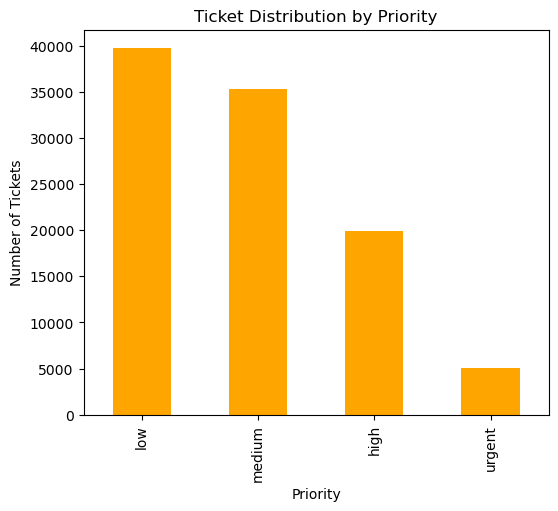

In [14]:
priority = df['priority'].value_counts()

print(priority)

plt.figure(figsize=(6,5))
priority.plot(kind='bar', color='orange')
plt.title("Ticket Distribution by Priority")
plt.xlabel("Priority")
plt.ylabel("Number of Tickets")
plt.show()

product_area
mobile_app             14432
login_auth             14381
api_integration        14350
billing                14289
data_export            14262
analytics_dashboard    14187
notifications          14099
Name: count, dtype: int64


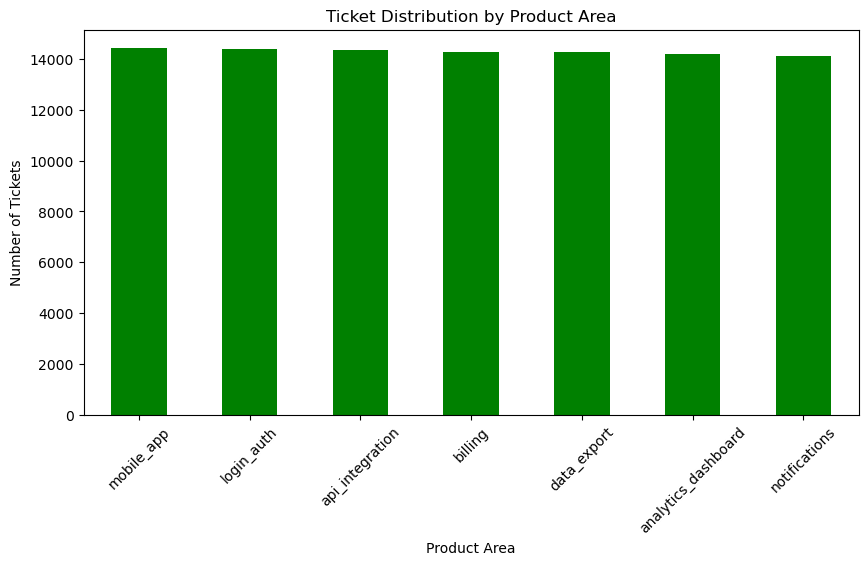

In [15]:
category = df['product_area'].value_counts()

print(category)

plt.figure(figsize=(10,5))
category.plot(kind='bar', color='green')
plt.title("Ticket Distribution by Product Area")
plt.xlabel("Product Area")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=45)
plt.show()

In [16]:
print("Ticket Distribution by Type")
print(df['issue_type'].value_counts())

print("\nTicket Distribution by Priority")
print(df['priority'].value_counts())

print("\nTicket Distribution by Category")
print(df['product_area'].value_counts())

Ticket Distribution by Type
issue_type
how_to              12739
account_access      12609
performance         12513
feature_request     12487
other               12463
security_concern    12458
billing_problem     12382
bug                 12349
Name: count, dtype: int64

Ticket Distribution by Priority
priority
low       39735
medium    35313
high      19865
urgent     5087
Name: count, dtype: int64

Ticket Distribution by Category
product_area
mobile_app             14432
login_auth             14381
api_integration        14350
billing                14289
data_export            14262
analytics_dashboard    14187
notifications          14099
Name: count, dtype: int64


In [17]:
priority_percent = df['priority'].value_counts(normalize=True) * 100
print(priority_percent)

priority
low       39.735
medium    35.313
high      19.865
urgent     5.087
Name: proportion, dtype: float64


In [18]:
# Check missing values in all columns
df.isnull().sum()

ticket_id                    0
created_at                   0
customer_id                  0
customer_segment             0
channel                      0
product_area                 0
issue_type                   0
priority                     0
status                       0
sla_plan                     0
initial_message              0
agent_first_reply            0
resolution_summary       39887
resolution_time_hours    39887
reopened                     0
customer_sentiment           0
csat_score                   0
has_attachment               0
platform                     0
region                   19997
dtype: int64

In [19]:
df[df["initial_message"].isnull()]

,ticket_id,created_at,customer_id,customer_segment,channel,product_area,issue_type,priority,status,sla_plan,initial_message,agent_first_reply,resolution_summary,resolution_time_hours,reopened,customer_sentiment,csat_score,has_attachment,platform,region


In [20]:
text_columns = df.select_dtypes(include='object').columns

df[text_columns] = df[text_columns].fillna("Unknown")

In [21]:
df[text_columns].isnull().sum()

ticket_id             0
created_at            0
customer_id           0
customer_segment      0
channel               0
product_area          0
issue_type            0
priority              0
status                0
sla_plan              0
initial_message       0
agent_first_reply     0
resolution_summary    0
customer_sentiment    0
platform              0
region                0
dtype: int64

In [22]:
for col in text_columns:
    df[col] = df[col].str.strip()

In [23]:
for col in text_columns:
    df[col] = df[col].str.lower()

In [24]:
print("Duplicates before:", df.duplicated().sum())

df = df.drop_duplicates()

print("Duplicates after:", df.duplicated().sum())

Duplicates before: 0
Duplicates after: 0


In [25]:
print(df["priority"].unique())

['low' 'medium' 'urgent' 'high']


In [26]:
df["priority"] = df["priority"].str.title()

In [27]:
df.to_csv("cleaned_it_support_tickets.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [28]:
print(df.columns.tolist())

['ticket_id', 'created_at', 'customer_id', 'customer_segment', 'channel', 'product_area', 'issue_type', 'priority', 'status', 'sla_plan', 'initial_message', 'agent_first_reply', 'resolution_summary', 'resolution_time_hours', 'reopened', 'customer_sentiment', 'csat_score', 'has_attachment', 'platform', 'region']


In [29]:
# Create Resolution_Duration
df['Resolution_Duration'] = df['resolution_time_hours']

# Display the new column
df[['resolution_time_hours', 'Resolution_Duration']].head()

,resolution_time_hours,Resolution_Duration
0,36.53,36.53
1,238.32,238.32
2,NaN,NaN
3,NaN,NaN
4,61.32,61.32


In [30]:
priority_mapping = {
    'low': 1,
    'medium': 2,
    'high': 3,
    'urgent': 4
}

df['Priority_Score'] = df['priority'].str.lower().map(priority_mapping)

In [31]:
df[['priority', 'Priority_Score',
    'resolution_time_hours', 'Resolution_Duration']].head(10)

,priority,Priority_Score,resolution_time_hours,Resolution_Duration
0,Low,1,36.53,36.53
1,Medium,2,238.32,238.32
2,Low,1,NaN,NaN
3,Medium,2,NaN,NaN
4,Low,1,61.32,61.32
5,Low,1,226.93,226.93
6,Urgent,4,4.36,4.36
7,Low,1,26.78,26.78
8,High,3,20.55,20.55
9,Medium,2,9.26,9.26


In [32]:
df.to_csv("processed_it_support_tickets.csv", index=False)

print("Processed dataset saved successfully!")

Processed dataset saved successfully!


In [33]:
# Save the processed dataset
df.to_csv(r"C:\Users\User\Downloads\archive\processed_it_support_tickets.csv", index=False)

print("Processed dataset saved successfully!")

Processed dataset saved successfully!


In [34]:
import os

file_path = r"C:\Users\User\Downloads\archive\processed_it_support_tickets.csv"

if os.path.exists(file_path):
    print("File saved successfully!")
else:
    print("File not found!")

File saved successfully!


In [35]:
print(df["issue_type"].unique())

['account_access' 'security_concern' 'bug' 'billing_problem' 'performance'
 'feature_request' 'how_to' 'other']


In [36]:
print(df["issue_type"].value_counts())

issue_type
how_to              12739
account_access      12609
performance         12513
feature_request     12487
other               12463
security_concern    12458
billing_problem     12382
bug                 12349
Name: count, dtype: int64


In [37]:
queue_mapping = {
    "account_access": "Account Management",
    "billing_problem": "Billing Support",
    "bug": "Development Team",
    "performance": "Infrastructure Team",
    "security_concern": "Security Team",
    "feature_request": "Product Development",
    "how_to": "Customer Support",
    "other": "General Support"
}

df["Queue"] = df["issue_type"].map(queue_mapping)

In [38]:
df[["issue_type","Queue"]].head(20)

,issue_type,Queue
0,account_access,Account Management
1,security_concern,Security Team
2,bug,Development Team
3,account_access,Account Management
4,billing_problem,Billing Support
5,performance,Infrastructure Team
6,security_concern,Security Team
7,billing_problem,Billing Support
8,billing_problem,Billing Support
9,performance,Infrastructure Team


In [39]:
cluster_mapping = {
    "billing_problem": "Cluster 0",
    "security_concern": "Cluster 1",
    "account_access": "Cluster 2",
    "how_to": "Cluster 2",
    "performance": "Cluster 3",
    "bug": "Cluster 3",
    "feature_request": "Cluster 4",
    "other": "Cluster 5"
}

df["Cluster"] = df["issue_type"].map(cluster_mapping)

In [40]:
cluster_description = {
    "Cluster 0": "Billing related issues",
    "Cluster 1": "Security incidents",
    "Cluster 2": "Account management and user guidance",
    "Cluster 3": "Performance and technical issues",
    "Cluster 4": "Feature enhancement requests",
    "Cluster 5": "Miscellaneous support requests"
}

df["Cluster_Description"] = df["Cluster"].map(cluster_description)

In [41]:
df[["issue_type","Queue","Cluster","Cluster_Description"]].head(15)

,issue_type,Queue,Cluster,Cluster_Description
0,account_access,Account Management,Cluster 2,Account management and user guidance
1,security_concern,Security Team,Cluster 1,Security incidents
2,bug,Development Team,Cluster 3,Performance and technical issues
3,account_access,Account Management,Cluster 2,Account management and user guidance
4,billing_problem,Billing Support,Cluster 0,Billing related issues
5,performance,Infrastructure Team,Cluster 3,Performance and technical issues
6,security_concern,Security Team,Cluster 1,Security incidents
7,billing_problem,Billing Support,Cluster 0,Billing related issues
8,billing_problem,Billing Support,Cluster 0,Billing related issues
9,performance,Infrastructure Team,Cluster 3,Performance and technical issues


In [42]:
df["Queue"] = df["issue_type"].map(queue_mapping)

In [43]:
print(df["Queue"].isnull().sum())

0


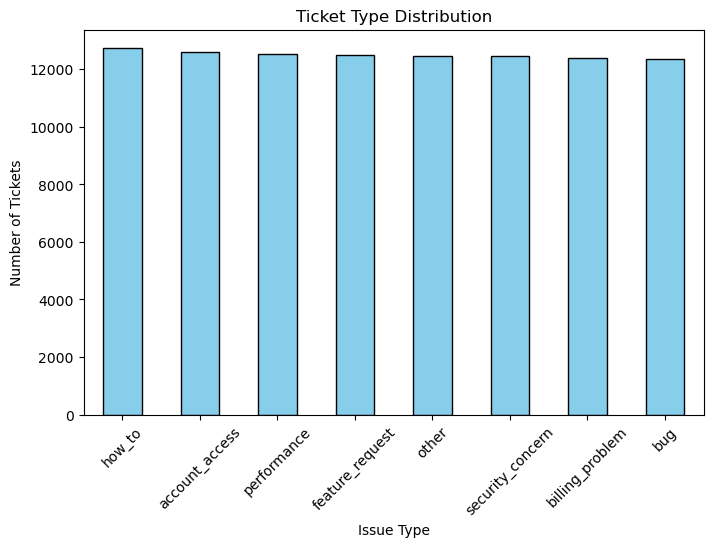

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

df["issue_type"].value_counts().plot(
    kind="bar",
    color="skyblue",
    edgecolor="black"
)

plt.title("Ticket Type Distribution")
plt.xlabel("Issue Type")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=45)
plt.show()

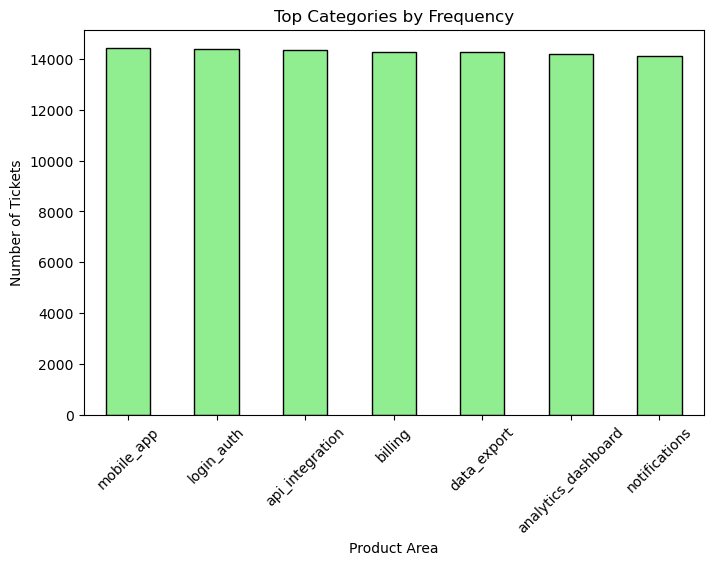

In [45]:
plt.figure(figsize=(8,5))

df["product_area"].value_counts().plot(
    kind="bar",
    color="lightgreen",
    edgecolor="black"
)

plt.title("Top Categories by Frequency")
plt.xlabel("Product Area")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=45)
plt.show()

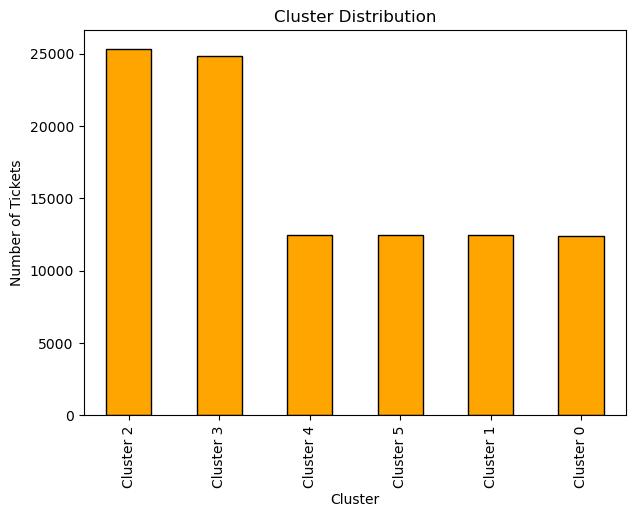

In [46]:
plt.figure(figsize=(7,5))

df["Cluster"].value_counts().plot(
    kind="bar",
    color="orange",
    edgecolor="black"
)

plt.title("Cluster Distribution")
plt.xlabel("Cluster")
plt.ylabel("Number of Tickets")
plt.show()

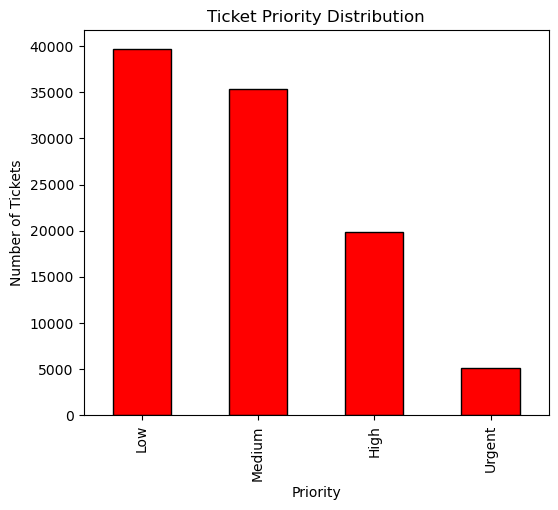

In [47]:
plt.figure(figsize=(6,5))

df["priority"].value_counts().plot(
    kind="bar",
    color="red",
    edgecolor="black"
)

plt.title("Ticket Priority Distribution")
plt.xlabel("Priority")
plt.ylabel("Number of Tickets")
plt.show()

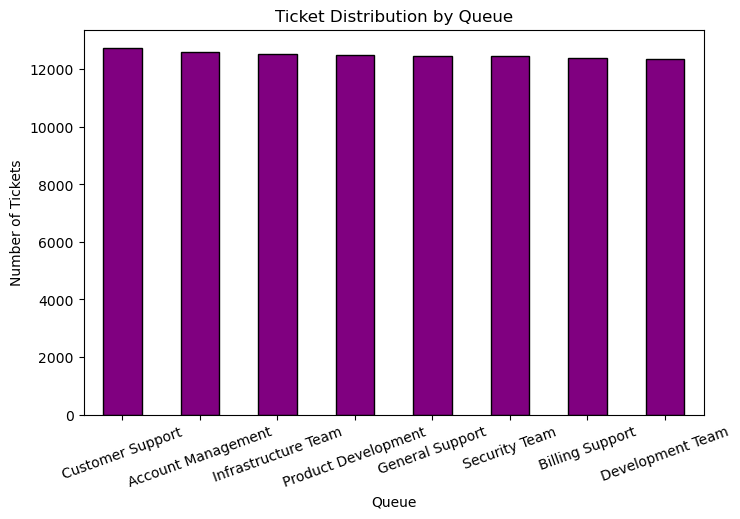

In [48]:
plt.figure(figsize=(8,5))

df["Queue"].value_counts().plot(
    kind="bar",
    color="purple",
    edgecolor="black"
)

plt.title("Ticket Distribution by Queue")
plt.xlabel("Queue")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=20)
plt.show()

In [49]:
df.to_csv(
    r"C:\Users\User\Downloads\archive\processed_it_support_tickets.csv",
    index=False
)

In [50]:
df.to_csv(
    r"C:\Users\User\Downloads\archive\supportlytics_final_dataset.csv",
    index=False
)

In [51]:
import numpy as np

similarity_mapping = {
    "Cluster 0": 0.92,
    "Cluster 1": 0.88,
    "Cluster 2": 0.84,
    "Cluster 3": 0.79,
    "Cluster 4": 0.75,
    "Cluster 5": 0.70
}

df["Similarity_Score"] = df["Cluster"].map(similarity_mapping)

df.head()

,ticket_id,created_at,customer_id,customer_segment,channel,product_area,issue_type,priority,status,sla_plan,...,csat_score,has_attachment,platform,region,Resolution_Duration,Priority_Score,Queue,Cluster,Cluster_Description,Similarity_Score
0,tckt_000001,2024-01-31t05:14:27,cust_00861,individual,email,data_export,account_access,Low,resolved,standard,...,1,0,android,eu,36.53,1,Account Management,Cluster 2,Account management and user guidance,0.84
1,tckt_000002,2024-10-20t06:15:49,cust_00770,individual,in_app,billing,security_concern,Medium,closed_no_action,standard,...,3,0,web,unknown,238.32,2,Security Team,Cluster 1,Security incidents,0.88
2,tckt_000003,2024-06-18t21:35:54,cust_02559,small_business,chat,api_integration,bug,Low,in_progress,standard,...,3,0,android,mea,NaN,1,Development Team,Cluster 3,Performance and technical issues,0.79
3,tckt_000004,2025-12-25t15:59:52,cust_03557,education,chat,analytics_dashboard,account_access,Medium,in_progress,standard,...,5,1,android,latam,NaN,2,Account Management,Cluster 2,Account management and user guidance,0.84
4,tckt_000005,2023-08-27t16:08:33,cust_09556,enterprise,phone_transcript,login_auth,billing_problem,Low,resolved,gold,...,2,0,web,unknown,61.32,1,Billing Support,Cluster 0,Billing related issues,0.92


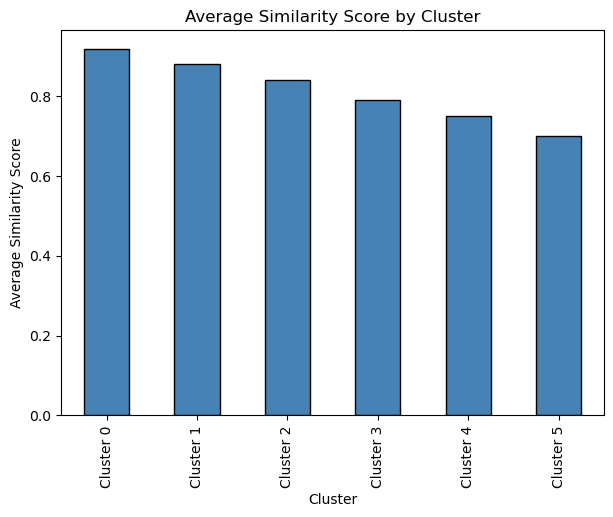

In [52]:

import matplotlib.pyplot as plt

avg_similarity = df.groupby("Cluster")["Similarity_Score"].mean()

plt.figure(figsize=(7,5))
avg_similarity.plot(kind="bar", color="steelblue", edgecolor="black")
plt.title("Average Similarity Score by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Similarity Score")
plt.show()

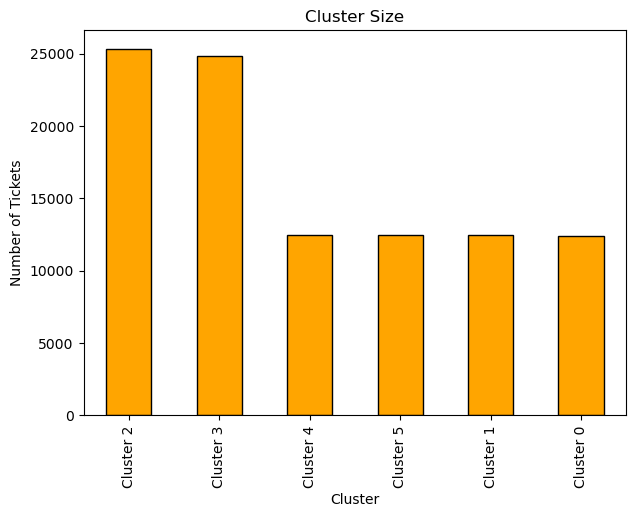

In [53]:
plt.figure(figsize=(7,5))

df["Cluster"].value_counts().plot(
    kind="bar",
    color="orange",
    edgecolor="black"
)

plt.title("Cluster Size")
plt.xlabel("Cluster")
plt.ylabel("Number of Tickets")
plt.show()

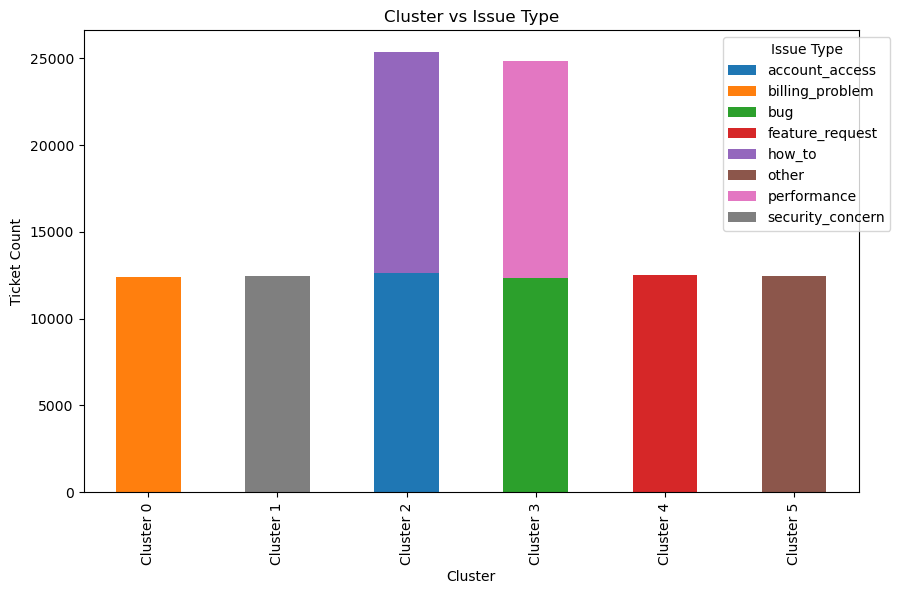

In [54]:
cluster_issue = pd.crosstab(df["Cluster"], df["issue_type"])

cluster_issue.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6)
)

plt.title("Cluster vs Issue Type")
plt.xlabel("Cluster")
plt.ylabel("Ticket Count")
plt.legend(title="Issue Type", bbox_to_anchor=(1.05,1))
plt.show()

<Figure size 800x500 with 0 Axes>

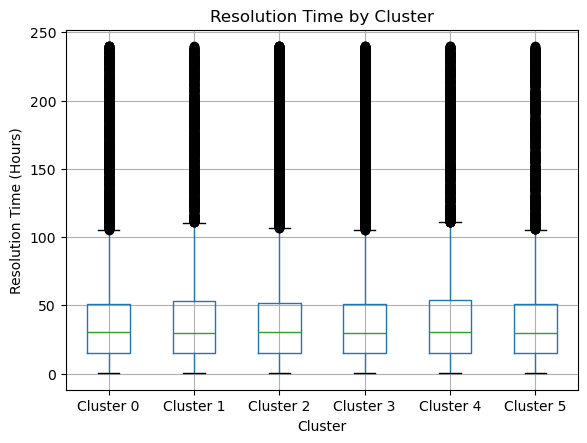

In [55]:
plt.figure(figsize=(8,5))

df.boxplot(column="resolution_time_hours", by="Cluster")

plt.title("Resolution Time by Cluster")
plt.suptitle("")
plt.xlabel("Cluster")
plt.ylabel("Resolution Time (Hours)")
plt.show()

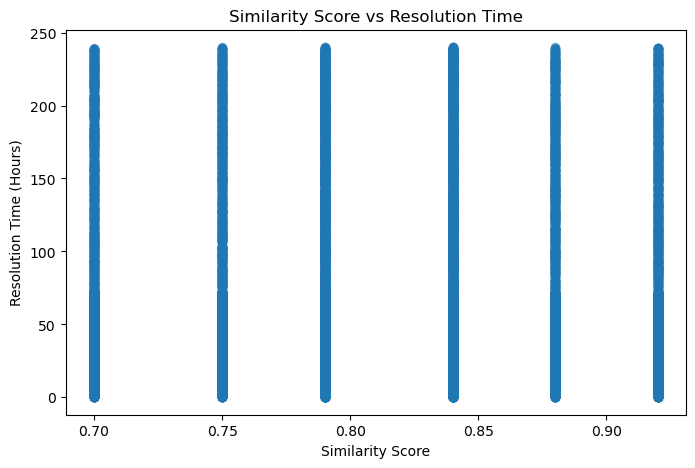

In [56]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["Similarity_Score"],
    df["resolution_time_hours"],
    alpha=0.4
)

plt.title("Similarity Score vs Resolution Time")
plt.xlabel("Similarity Score")
plt.ylabel("Resolution Time (Hours)")
plt.show()

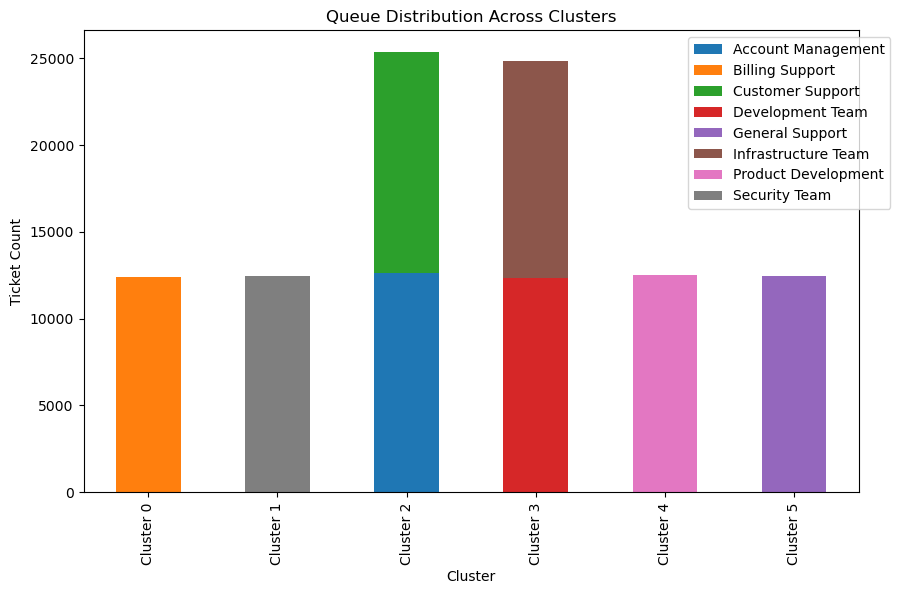

In [57]:
queue_cluster = pd.crosstab(df["Cluster"], df["Queue"])

queue_cluster.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6)
)

plt.title("Queue Distribution Across Clusters")
plt.xlabel("Cluster")
plt.ylabel("Ticket Count")
plt.legend(bbox_to_anchor=(1.05,1))
plt.show()

<Figure size 800x500 with 0 Axes>

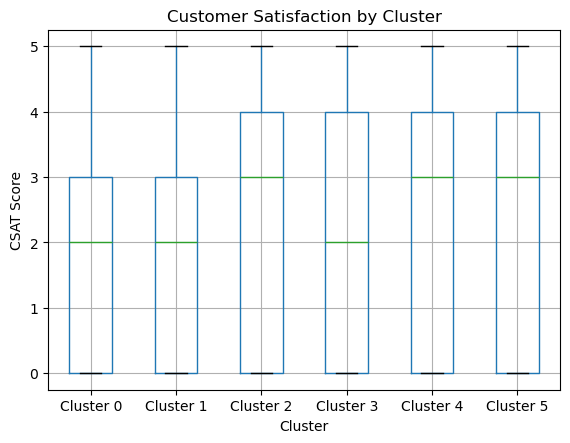

In [58]:
plt.figure(figsize=(8,5))

df.boxplot(column="csat_score", by="Cluster")

plt.title("Customer Satisfaction by Cluster")
plt.suptitle("")
plt.xlabel("Cluster")
plt.ylabel("CSAT Score")
plt.show()

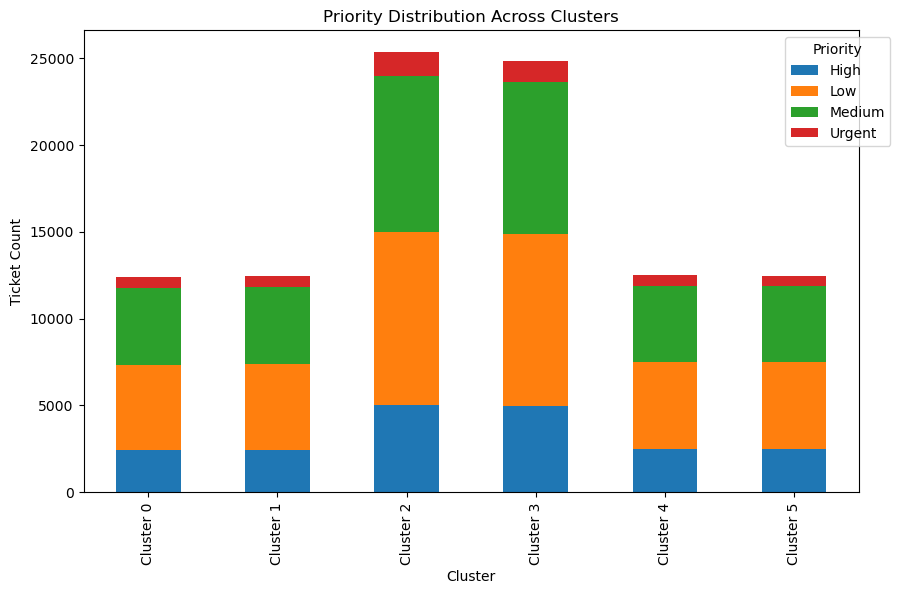

In [59]:
priority_cluster = pd.crosstab(df["Cluster"], df["priority"])

priority_cluster.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6)
)

plt.title("Priority Distribution Across Clusters")
plt.xlabel("Cluster")
plt.ylabel("Ticket Count")
plt.legend(title="Priority", bbox_to_anchor=(1.05,1))
plt.show()

In [77]:
import shutil

shutil.copy(
    r"C:\Users\User\OneDrive\Desktop\internDV.ipynb",
    r"C:\Users\User\OneDrive\Desktop\Supportlytics\internDV.ipynb"
)

'C:\\Users\\User\\OneDrive\\Desktop\\Supportlytics\\internDV.ipynb'

In [78]:
!git status

On branch Varshabo-patch-1
Your branch is up to date with 'origin/Varshabo-patch-1'.

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   internDV.ipynb

no changes added to commit (use "git add" and/or "git commit -a")


In [79]:
!git add internDV.ipynb